# Load All Task Run Reports

This notebook loads every report matching:

`logs/<model name>/<run name>/task_run_report.json`

It creates reusable pandas DataFrames for run-level summaries, task-level results, and per-tool appropriateness scores. Use this as the first notebook when you want to compare multiple models or inspect all experiment outputs together.

## How To Use

1. Select the repo `.venv` kernel in VS Code/Jupyter.
2. Run the import/config cells.
3. Leave `MODEL_FILTER = None` to load every model folder under `logs/`.
4. Set `MODEL_FILTER` to a model folder name, or a list of folder names, to load only selected models.
5. Use `reports_df` for one row per run, `task_runs_df` for one row per task-run, and `tool_scores_df` for one row per scored tool call.

In [19]:
from __future__ import annotations

import json
import re
from pathlib import Path
import pandas as pd

try:
    import pandas as pd
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook needs pandas. Select the project .venv kernel, "
        "or install dependencies with: uv sync"
    ) from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Configuration

Change only this cell for most use cases. The notebook is written to work whether you run it from the repo root or from the `analysis/` folder.

In [20]:
# Set to None to load every model folder under logs/.
# Examples:
# MODEL_FILTER = "qwen3.6-plus"
# MODEL_FILTER = ["qwen3.6-plus", "gpt5.5"]
MODEL_FILTER = None

# Set True if you want CSV copies of the DataFrames written to analysis/outputs/.
EXPORT_CSV = False

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "analysis" else Path(".").resolve()
LOGS_ROOT = PROJECT_ROOT / "logs"
OUTPUT_DIR = PROJECT_ROOT / "analysis" / "outputs"

assert LOGS_ROOT.exists(), f"Logs folder not found: {LOGS_ROOT}"

## Discover Reports

This scans only one level below each model folder, so it includes paths shaped like `logs/model/run/task_run_report.json` and skips deeper archival folders such as `logs/results/...`.

In [21]:
def normalise_model_filter(model_filter):
    if model_filter is None:
        return None
    if isinstance(model_filter, str):
        return {model_filter}
    return set(model_filter)


def discover_report_paths(logs_root: Path, model_filter=None) -> list[Path]:
    allowed_models = normalise_model_filter(model_filter)
    report_paths = []

    for model_dir in sorted(p for p in logs_root.iterdir() if p.is_dir()):
        if allowed_models is not None and model_dir.name not in allowed_models:
            continue

        for run_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
            report_path = run_dir / "task_run_report.json"
            if report_path.exists():
                report_paths.append(report_path)

    return report_paths


report_paths = discover_report_paths(LOGS_ROOT, MODEL_FILTER)
print(f"Found {len(report_paths)} reports")
for path in report_paths[:10]:
    print(path.relative_to(PROJECT_ROOT))

Found 21 reports
logs\claude-optus-4.6\1anthropic_claude-opus-4.6_20260512T084016Z\task_run_report.json
logs\claude-optus-4.6\2anthropic_claude-opus-4.6_20260516T090351Z\task_run_report.json
logs\claude-optus-4.6\3anthropic_claude-opus-4.6_20260512T082634Z\task_run_report.json
logs\claude-sonnet-4.6\1anthropic_claude-sonnet-4.6_20260512T072817Z\task_run_report.json
logs\claude-sonnet-4.6\2anthropic_claude-sonnet-4.6_20260512T073036Z\task_run_report.json
logs\claude-sonnet-4.6\3anthropic_claude-sonnet-4.6_20260512T073516Z\task_run_report.json
logs\deepseek-v4-pro\1deepseek_deepseek-v4-pro_20260607T074126Z\task_run_report.json
logs\deepseek-v4-pro\2deepseek_deepseek-v4-pro_20260607T080902Z\task_run_report.json
logs\deepseek-v4-pro\3deepseek_deepseek-v4-pro_20260607T083808Z\task_run_report.json
logs\gpt5.5\1openai_gpt-5.5_20260512T075029Z\task_run_report.json


## Load JSON Reports

`reports` keeps the raw JSON objects in memory. The following cells flatten those objects into DataFrames while preserving the original model folder, run folder, and report path for traceability.

In [22]:
def read_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def leading_run_index(run_name: str):
    match = re.match(r"^(\d+)", run_name)
    return int(match.group(1)) if match else None


reports = []
for report_path in report_paths:
    run_dir = report_path.parent
    model_dir = run_dir.parent
    report = read_json(report_path)
    reports.append({
        "model_name": model_dir.name,
        "run_name": run_dir.name,
        "run_index": leading_run_index(run_dir.name),
        "report_path": str(report_path.relative_to(PROJECT_ROOT)),
        "report": report,
    })

len(reports)

21

## Build DataFrames

- `reports_df`: one row per `task_run_report.json`, mostly run-level summary fields.
- `task_runs_df`: one row per task result inside each report.
- `tool_scores_df`: one row per scored tool call from the `tool_appropriateness` section, when present.

In [23]:
report_rows = []
task_rows = []
tool_score_rows = []

for item in reports:
    report = item["report"]
    summary = report.get("summary", {}) or {}
    base = {
        "model_name": item["model_name"],
        "run_name": item["run_name"],
        "run_index": item["run_index"],
        "report_path": item["report_path"],
        "generated_at": report.get("generated_at"),
        "source_csv": "task/taskset35-updated2.csv"#report.get("source_csv"),
    }
    

    report_rows.append({**base, **summary})

    for result in report.get("results", []) or []:
        validation = result.get("ground_truth_validation") or {}
        query_trace = result.get("query_trace") or {}
        tool_appropriateness = result.get("tool_appropriateness") or {}

        task_base = {
            **base,
            "task_id": result.get("task_id"),
            "prompt": result.get("prompt"),
            "status": result.get("status"),
            "answer_type": result.get("answer_type"),
            "passed": validation.get("passed", result.get("passed")),
            "ground_truth_score": validation.get("score"),
            "validation_strategy": validation.get("strategy"),
            "parameter_schema_valid_rate": result.get("parameter_schema_valid_rate"),
            "constraint_compliance_rate": result.get("constraint_compliance_rate"),
            "tool_appropriateness": tool_appropriateness.get("average_score"),
            "tool_appropriateness_weighted": tool_appropriateness.get("weighted_score"),
            "total_tokens": result.get("total_tokens"),
            "input_tokens": query_trace.get("input_tokens"),
            "output_tokens": query_trace.get("output_tokens"),
            "total_steps": result.get("total_steps"),
            "total_tool_calls": result.get("total_tool_calls"),
            "latency": result.get("latency"),
            "end_to_end_latency": result.get("end_to_end_latency"),
            "attempt_count": result.get("attempt_count"),
            "tools_used": result.get("tools_used") or query_trace.get("tools_used"),
            "final_answer": query_trace.get("final_answer", result.get("final_answer")),
        }
        task_rows.append(task_base)

        for call_index, scored_call in enumerate(tool_appropriateness.get("scored_calls") or [], start=1):
            tool_score_rows.append({
                **base,
                "task_id": result.get("task_id"),
                "call_index": call_index,
                **scored_call,
            })

reports_df = pd.DataFrame(report_rows)
task_runs_df = pd.DataFrame(task_rows)
tool_scores_df = pd.DataFrame(tool_score_rows)

if not task_runs_df.empty:
    task_runs_df["passed"] = task_runs_df["passed"].astype("boolean")
    numeric_columns = [
        "ground_truth_score",
        "parameter_schema_valid_rate",
        "constraint_compliance_rate",
        "tool_appropriateness",
        "tool_appropriateness_weighted",
        "total_tokens",
        "input_tokens",
        "output_tokens",
        "total_steps",
        "total_tool_calls",
        "latency",
        "end_to_end_latency",
        "attempt_count",
    ]
    for col in numeric_columns:
        if col in task_runs_df.columns:
            task_runs_df[col] = pd.to_numeric(task_runs_df[col], errors="coerce")

if not tool_scores_df.empty and "score" in tool_scores_df.columns:
    tool_scores_df["score"] = pd.to_numeric(tool_scores_df["score"], errors="coerce")

print(f"reports_df: {reports_df.shape[0]} rows x {reports_df.shape[1]} columns")
print(f"task_runs_df: {task_runs_df.shape[0]} rows x {task_runs_df.shape[1]} columns")
print(f"tool_scores_df: {tool_scores_df.shape[0]} rows x {tool_scores_df.shape[1]} columns")

reports_df: 21 rows x 28 columns
task_runs_df: 735 rows x 27 columns
tool_scores_df: 3845 rows x 12 columns


## Quick Checks

These lightweight checks confirm which models and runs were loaded. If a model is missing, check that its reports are located exactly one folder below its model folder.

In [24]:
display(
    reports_df[["model_name", "run_name", "run_index", "generated_at", "model", "total_tasks", "Task Completion Rate (TCR)"]]
    .sort_values(["model_name", "run_index", "run_name"])
)

display(task_runs_df.head())
display(tool_scores_df.head())

,model_name,run_name,run_index,generated_at,model,total_tasks,Task Completion Rate (TCR)
0,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,2026-05-22T06:09:39Z,anthropic/claude-opus-4.6,35,0.9714
1,claude-optus-4.6,2anthropic_claude-opus-4.6_20260516T090351Z,2,2026-05-22T06:09:39Z,anthropic/claude-opus-4.6,35,0.9429
2,claude-optus-4.6,3anthropic_claude-opus-4.6_20260512T082634Z,3,2026-05-22T06:09:39Z,anthropic/claude-opus-4.6,35,1.0000
3,claude-sonnet-4.6,1anthropic_claude-sonnet-4.6_20260512T072817Z,1,2026-06-01T11:27:30Z,anthropic/claude-sonnet-4.6,35,0.9714
4,claude-sonnet-4.6,2anthropic_claude-sonnet-4.6_20260512T073036Z,2,2026-05-22T06:09:39Z,anthropic/claude-sonnet-4.6,35,0.9143
5,claude-sonnet-4.6,3anthropic_claude-sonnet-4.6_20260512T073516Z,3,2026-05-22T06:09:39Z,anthropic/claude-sonnet-4.6,35,0.8571
6,deepseek-v4-pro,1deepseek_deepseek-v4-pro_20260607T074126Z,1,2026-06-09T05:26:20Z,deepseek/deepseek-v4-pro,35,0.9714
7,deepseek-v4-pro,2deepseek_deepseek-v4-pro_20260607T080902Z,2,2026-06-09T05:27:14Z,deepseek/deepseek-v4-pro,35,0.9143
8,deepseek-v4-pro,3deepseek_deepseek-v4-pro_20260607T083808Z,3,2026-06-09T05:28:12Z,deepseek/deepseek-v4-pro,35,0.8571
9,gpt5.5,1openai_gpt-5.5_20260512T075029Z,1,2026-05-22T06:09:39Z,openai/gpt-5.5,35,0.8571


,model_name,run_name,run_index,report_path,generated_at,source_csv,task_id,prompt,status,answer_type,passed,ground_truth_score,validation_strategy,parameter_schema_valid_rate,constraint_compliance_rate,tool_appropriateness,tool_appropriateness_weighted,total_tokens,input_tokens,output_tokens,total_steps,total_tool_calls,latency,end_to_end_latency,attempt_count,tools_used,final_answer
0,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A1,how many posts does twitter collection have?,completed,scalar,True,1,scalar_deterministic,1.0000,NaN,1.0000,1.0000,"9,279.0000","9,171.0000",108.0000,2.0000,1.0000,6.0292,6.0391,1,[get_collection_summary],"{""status"":""success"",""answer"":{""value"":18587322..."
1,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A2,Compare the harvesting date span of all availa...,completed,text,True,1,text_judge,1.0000,NaN,1.0000,8.0000,"15,794.0000","14,653.0000","1,141.0000",3.0000,8.0000,18.8210,29.9182,1,"[get_collections, get_collection_summary, get_...",Now I have all the data. Let me compute the ha...
2,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A3,"Compare Reddit, Mastodon, and Twitter by total...",completed,text,True,1,text_judge,1.0000,NaN,1.0000,4.0000,"14,827.0000","14,220.0000",607.0000,3.0000,4.0000,15.8184,27.4085,1,"[get_collections, get_collection_summary, get_...",I now have all the data needed to provide a co...
3,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A4,List all available collections and their start...,completed,text,True,1,text_judge,1.0000,NaN,1.0000,8.0000,"15,200.0000","14,597.0000",603.0000,3.0000,8.0000,13.7425,22.1047,1,"[get_collections, get_collection_summary, get_...","{\n ""status"": ""success"",\n ""answer"": {\n ..."
4,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A5,Which available collections have harvesting da...,completed,text,True,1,text_judge,1.0000,NaN,1.0000,8.0000,"15,348.0000","14,647.0000",701.0000,3.0000,8.0000,13.6640,22.8235,1,"[get_collections, get_collection_summary, get_...",I now have all the data needed to answer the q...


,model_name,run_name,run_index,report_path,generated_at,source_csv,task_id,call_index,tool_name,category,appropriateness,score
0,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A1,1,get_collection_summary,core,core,1.0000
1,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A2,1,get_collections,core,core,1.0000
2,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A2,2,get_collection_summary,core,core,1.0000
3,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A2,3,get_collection_summary,core,core,1.0000
4,claude-optus-4.6,1anthropic_claude-opus-4.6_20260512T084016Z,1,logs\claude-optus-4.6\1anthropic_claude-opus-4...,2026-05-22T06:09:39Z,task/taskset35-updated2.csv,A2,4,get_collection_summary,core,core,1.0000


## Example Aggregations

These are optional examples showing how to start comparing models. You can copy and modify these cells for your thesis tables.

In [25]:
model_summary = task_runs_df.groupby("model_name", as_index=False).agg(
    runs=("run_name", "nunique"),
    task_runs=("task_id", "count"),
    unique_tasks=("task_id", "nunique"),
    tcr=("passed", "mean"),
    average_psv=("parameter_schema_valid_rate", "mean"),
    average_ccr=("constraint_compliance_rate", "mean"),
    average_tool_appropriateness=("tool_appropriateness", "mean"),
    average_latency=("latency", "mean"),
    average_tokens=("total_tokens", "mean"),
)

display(model_summary.sort_values("model_name"))

,model_name,runs,task_runs,unique_tasks,tcr,average_psv,average_ccr,average_tool_appropriateness,average_latency,average_tokens
0,claude-optus-4.6,3,105,35,0.9714,1.0000,0.9174,0.8403,24.5356,"19,048.6381"
1,claude-sonnet-4.6,3,105,35,0.9143,1.0000,0.9131,0.7930,23.3425,"21,043.4190"
2,deepseek-v4-pro,3,105,35,0.9143,1.0000,0.9009,0.7250,52.9553,"28,257.8462"
3,gpt5.5,3,105,35,0.8762,0.9981,1.0000,0.9168,22.4569,"10,323.2190"
4,kimi-k2.6,3,105,35,0.8952,1.0000,0.9130,0.8486,83.5357,"22,186.2286"
5,llama4,3,105,35,0.0667,0.9861,0.7698,0.8147,20.7645,"10,227.3131"
6,qwen3.6-plus,3,105,35,0.8857,1.0000,0.9194,0.8358,53.4232,"23,452.5905"


## TCR by Task Category @ 1

Task category is inferred from the first letter of `task_id`. For example, `A1` to `A7` are category `A`.

Category labels:

- **A**: Discovery & Dataset Overview
- **B**: Filtered Counting & Lookup
- **C**: Aggregation & Temporal Pattern Analysis
- **D**: Comparative Analysis
- **E**: Exploratory NLP Analysis


the table displays TCR for run_index=1 by task category and overall TCR for each model

In [26]:
task_category_labels = {
    "A": "Discovery & Dataset Overview",
    "B": "Filtered Counting & Lookup",
    "C": "Aggregation & Temporal Pattern Analysis",
    "D": "Comparative Analysis",
    "E": "Exploratory NLP Analysis",
}

run_order_lookup_tcr1 = (
    reports_df[["model_name", "run_name", "run_index"]]
    .drop_duplicates()
    .assign(run_index_numeric=lambda df: pd.to_numeric(df["run_index"], errors="coerce"))
    .sort_values(["model_name", "run_index_numeric", "run_name"], na_position="last", kind="stable")
)
run_order_lookup_tcr1["run_order"] = run_order_lookup_tcr1.groupby("model_name").cumcount().add(1)

task_runs_with_category_tcr1 = (
    task_runs_df.merge(
        run_order_lookup_tcr1[["model_name", "run_name", "run_order"]],
        on=["model_name", "run_name"],
        how="left",
    )
    .assign(
        task_category=lambda df: df["task_id"].astype(str).str[0],
        task_category_name=lambda df: df["task_id"].astype(str).str[0].map(task_category_labels),
    )
)

tcr_by_task_category_at_1 = (
    task_runs_with_category_tcr1[task_runs_with_category_tcr1["run_order"].eq(1)]
    .groupby(["model_name", "task_category"], as_index=False)
    .agg(tcr_at_1=("passed", "mean"))
)

overall_tcr_at_1 = (
    task_runs_with_category_tcr1[task_runs_with_category_tcr1["run_order"].eq(1)]
    .groupby("model_name", as_index=False)
    .agg(overall_tcr_at_1=("passed", "mean"))
)

task_category_row_labels = {
    "A": "A: Discovery & Dataset Overview",
    "B": "B: Filtered Counting & Lookup",
    "C": "C: Aggregation & Temporal Pattern Analysis",
    "D": "D: Comparative Analysis",
    "E": "E: Exploratory NLP Analysis",
}

tcr_by_task_category_at_1_table = (
    tcr_by_task_category_at_1.pivot(index="task_category", columns="model_name", values="tcr_at_1")
    .reindex(index=["A", "B", "C", "D", "E"])
    .rename(index=task_category_row_labels)
)

tcr_by_task_category_at_1_table.loc["Overall TCR @ 1"] = (
    overall_tcr_at_1.set_index("model_name")["overall_tcr_at_1"]
)

display(tcr_by_task_category_at_1_table)

model_name,claude-optus-4.6,claude-sonnet-4.6,deepseek-v4-pro,gpt5.5,kimi-k2.6,llama4,qwen3.6-plus
task_category,,,,,,,
A: Discovery & Dataset Overview,1.0000,1.0000,1.0000,1.0000,1.0000,0.1429,1.0000
B: Filtered Counting & Lookup,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000
C: Aggregation & Temporal Pattern Analysis,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.8571
D: Comparative Analysis,1.0000,0.8571,0.8571,0.5714,0.8571,0.0000,0.8571
E: Exploratory NLP Analysis,0.8571,1.0000,1.0000,0.7143,0.8571,0.0000,0.5714
Overall TCR @ 1,0.9714,0.9714,0.9714,0.8571,0.9429,0.0286,0.8571


## Overall Task Completion Performance @ k = 3

This table uses the same format as the `TCR by Task Category @ 1` table, but reports overall task completion performance at `k = 3`, where a task is counted as completed if the model passed it in at least one of the three runs.

In [27]:
overall_task_completion_by_category_at_3 = (
    task_runs_with_category_tcr1.groupby(["model_name", "task_id", "task_category"], as_index=False)
    .agg(passed_at_least_once=("passed", "any"))
)

overall_task_completion_by_category_at_3_summary = (
    overall_task_completion_by_category_at_3.groupby(["model_name", "task_category"], as_index=False)
    .agg(task_completion_at_3=("passed_at_least_once", "mean"))
)

overall_task_completion_at_3 = (
    overall_task_completion_by_category_at_3.groupby("model_name", as_index=False)
    .agg(overall_task_completion_at_3=("passed_at_least_once", "mean"))
)

overall_task_completion_performance_at_3_table = (
    overall_task_completion_by_category_at_3_summary.pivot(
        index="task_category",
        columns="model_name",
        values="task_completion_at_3",
    )
    .reindex(index=["A", "B", "C", "D", "E"])
    .rename(index=task_category_row_labels)
)

overall_task_completion_performance_at_3_table.loc["Overall Task Completion @ 3"] = (
    overall_task_completion_at_3.set_index("model_name")["overall_task_completion_at_3"]
)

display(overall_task_completion_performance_at_3_table)

model_name,claude-optus-4.6,claude-sonnet-4.6,deepseek-v4-pro,gpt5.5,kimi-k2.6,llama4,qwen3.6-plus
task_category,,,,,,,
A: Discovery & Dataset Overview,1.0000,1.0000,1.0000,1.0000,1.0000,0.4286,1.0000
B: Filtered Counting & Lookup,1.0000,1.0000,1.0000,1.0000,1.0000,0.1429,1.0000
C: Aggregation & Temporal Pattern Analysis,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.8571
D: Comparative Analysis,1.0000,1.0000,1.0000,1.0000,0.8571,0.0000,1.0000
E: Exploratory NLP Analysis,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000
Overall Task Completion @ 3,1.0000,1.0000,1.0000,1.0000,0.9714,0.1143,0.9714


## Task Completion Performance ^ 1

This table uses the same format as the previous two tables, but reports task completion performance `^1`, defined here as the mean success rate across `n = 3` independent trials per task.

In [28]:
task_completion_per_task_hat_1 = (
    task_runs_with_category_tcr1.groupby(["model_name", "task_id", "task_category"], as_index=False)
    .agg(task_success_rate_hat_1=("passed", "mean"))
)

task_completion_by_category_hat_1 = (
    task_completion_per_task_hat_1.groupby(["model_name", "task_category"], as_index=False)
    .agg(task_completion_hat_1=("task_success_rate_hat_1", "mean"))
)

overall_task_completion_hat_1 = (
    task_completion_per_task_hat_1.groupby("model_name", as_index=False)
    .agg(overall_task_completion_hat_1=("task_success_rate_hat_1", "mean"))
)

task_completion_performance_hat_1_table = (
    task_completion_by_category_hat_1.pivot(
        index="task_category",
        columns="model_name",
        values="task_completion_hat_1",
    )
    .reindex(index=["A", "B", "C", "D", "E"])
    .rename(index=task_category_row_labels)
)

task_completion_performance_hat_1_table.loc["Overall Task Completion ^ 1"] = (
    overall_task_completion_hat_1.set_index("model_name")["overall_task_completion_hat_1"]
)

display(task_completion_performance_hat_1_table)

model_name,claude-optus-4.6,claude-sonnet-4.6,deepseek-v4-pro,gpt5.5,kimi-k2.6,llama4,qwen3.6-plus
task_category,,,,,,,
A: Discovery & Dataset Overview,1.0000,1.0000,0.9048,1.0000,1.0000,0.2857,1.0000
B: Filtered Counting & Lookup,1.0000,1.0000,0.9048,0.9048,1.0000,0.0476,0.9524
C: Aggregation & Temporal Pattern Analysis,1.0000,0.9048,0.9048,1.0000,0.9524,0.0000,0.8571
D: Comparative Analysis,0.9524,0.7619,0.9048,0.7143,0.7619,0.0000,0.9048
E: Exploratory NLP Analysis,0.9048,0.9048,0.9524,0.7619,0.7619,0.0000,0.7143
Overall Task Completion ^ 1,0.9714,0.9143,0.9143,0.8762,0.8952,0.0667,0.8857


## Task Completion Performance ^ 1 by Task Demand Profile

This table reports task completion performance `^1` grouped by the task label `Task demand profile` from the task set CSV.

In [29]:
task_metadata_df = pd.read_csv(PROJECT_ROOT / "task" / "taskset35-updated2.csv")

task_completion_per_task_hat_1_with_demand = task_completion_per_task_hat_1.merge(
    task_metadata_df[["task_id", "task_demand_profile"]],
    on="task_id",
    how="left",
)

task_completion_by_demand_profile_hat_1 = (
    task_completion_per_task_hat_1_with_demand.groupby(["model_name", "task_demand_profile"], as_index=False)
    .agg(task_completion_hat_1=("task_success_rate_hat_1", "mean"))
)

task_completion_performance_hat_1_by_demand_profile_table = (
    task_completion_by_demand_profile_hat_1.pivot(
        index="task_demand_profile",
        columns="model_name",
        values="task_completion_hat_1",
    )
    .reindex(index=["A", "BR", "D", "S"])
    .rename_axis(index="Task demand profile")
)

task_completion_performance_hat_1_by_demand_profile_table.loc["Overall Task Completion ^ 1"] = (
    overall_task_completion_hat_1.set_index("model_name")["overall_task_completion_hat_1"]
)

display(task_completion_performance_hat_1_by_demand_profile_table)

model_name,claude-optus-4.6,claude-sonnet-4.6,deepseek-v4-pro,gpt5.5,kimi-k2.6,llama4,qwen3.6-plus
Task demand profile,,,,,,,
A,0.9583,0.9167,0.9167,0.7917,0.8333,0.0000,0.7917
BR,1.0000,1.0000,0.9048,1.0000,1.0000,0.1429,1.0000
D,1.0000,1.0000,1.0000,0.9048,1.0000,0.1905,0.9524
S,0.9487,0.8205,0.8718,0.8462,0.8205,0.0000,0.8462
Overall Task Completion ^ 1,0.9714,0.9143,0.9143,0.8762,0.8952,0.0667,0.8857


## Mean TCR and Pass@3

This table reports the mean task completion rate across runs for each model and Pass@3, defined as the share of unique tasks that passed in at least one of the model's runs.

In [30]:
tcr_by_run = task_runs_df.groupby(["model_name", "run_name"], as_index=False).agg(
    task_runs=("task_id", "count"),
    successful_task_runs=("passed", "sum"),
    task_completion_rate=("passed", "mean"),
)

pass_at_3_by_task = task_runs_df.groupby(["model_name", "task_id"], as_index=False).agg(
    passed_at_least_once=("passed", "any"),
)

mean_tcr_pass3 = tcr_by_run.groupby("model_name", as_index=False).agg(
    #runs=("run_name", "nunique"),
    mean_task_completion_rate=("task_completion_rate", "mean"),
).merge(
    pass_at_3_by_task.groupby("model_name", as_index=False).agg(
        #unique_tasks=("task_id", "count"),
        tasks_passed_at_least_once=("passed_at_least_once", "sum"),
        pass_at_3=("passed_at_least_once", "mean"),
    ),
    on="model_name",
    how="left",
)

display(mean_tcr_pass3.sort_values("mean_task_completion_rate", ascending=False))

,model_name,mean_task_completion_rate,tasks_passed_at_least_once,pass_at_3
0,claude-optus-4.6,0.9714,35,1.0000
1,claude-sonnet-4.6,0.9143,35,1.0000
2,deepseek-v4-pro,0.9143,35,1.0000
4,kimi-k2.6,0.8952,34,0.9714
6,qwen3.6-plus,0.8857,34,0.9714
3,gpt5.5,0.8762,35,1.0000
5,llama4,0.0667,4,0.1143


## Reliability Across Repeated Runs

Run order uses `run_index` when available and otherwise falls back to sorted `run_name`.

- `pass@k` = proportion of tasks passed in at least one of `k` runs.
- `pass^k` = proportion of tasks passed in all `k` runs.

Chart 1 reports run-level TCR and repeated-run reliability. Chart 2 shows the distribution of how many of the three runs passed for each task.

In [31]:
run_order_lookup = (
    reports_df[["model_name", "run_name", "run_index"]]
    .drop_duplicates()
    .assign(run_index_numeric=lambda df: pd.to_numeric(df["run_index"], errors="coerce"))
    .sort_values(["model_name", "run_index_numeric", "run_name"], na_position="last", kind="stable")
)
run_order_lookup["run_order"] = run_order_lookup.groupby("model_name").cumcount().add(1)

task_runs_with_order = (
    task_runs_df.merge(
        run_order_lookup[["model_name", "run_name", "run_order"]],
        on=["model_name", "run_name"],
        how="left",
    )
    .assign(passed_int=lambda df: df["passed"].astype("Int64"))
)

run_level_tcr = (
    task_runs_with_order[task_runs_with_order["run_order"].isin([1, 2, 3])]
    .groupby(["model_name", "run_order"], as_index=False)
    .agg(tcr=("passed_int", "mean"))
)

run_level_tcr_wide = (
    run_level_tcr.pivot(index="model_name", columns="run_order", values="tcr")
    .rename(columns={1: "TCR Run 1", 2: "TCR Run 2", 3: "TCR Run 3"})
    .reset_index()
)

task_pass_by_run = (
    task_runs_with_order[task_runs_with_order["run_order"].isin([1, 2, 3])]
    .pivot_table(
        index=["model_name", "task_id"],
        columns="run_order",
        values="passed_int",
        aggfunc="max",
    )
    .reindex(columns=[1, 2, 3])
    .fillna(0)
    .astype(int)
)

task_pass_at_k = task_pass_by_run.cummax(axis=1)
task_pass_all_k = task_pass_by_run.cummin(axis=1)

pass_at_k = (
    task_pass_at_k.rename(columns={1: "pass@1", 2: "pass@2", 3: "pass@3"})
    .groupby(level="model_name")
    .mean()
    .reset_index()
)

pass_hat_k = (
    task_pass_all_k.rename(columns={1: "pass^1", 2: "pass^2", 3: "pass^3"})
    .groupby(level="model_name")
    .mean()
    .reset_index()
)

reliability_chart_1 = (
    run_level_tcr_wide.merge(pass_at_k[["model_name", "pass@3"]], on="model_name", how="left")
    .merge(pass_hat_k[["model_name", "pass^3"]], on="model_name", how="left")
    .assign(
        **{
            "Mean TCR": lambda df: df[["TCR Run 1", "TCR Run 2", "TCR Run 3"]].mean(axis=1),
        }
    )[["model_name", "TCR Run 1", "TCR Run 2", "TCR Run 3", "Mean TCR", "pass@3", "pass^3"]]
)

reliability_repeated_runs = reliability_chart_1.sort_values("Mean TCR", ascending=False)

passed_runs_distribution = (
    task_pass_by_run.sum(axis=1)
    .rename("passed_runs")
    .reset_index()
)
passed_runs_distribution["bucket"] = passed_runs_distribution["passed_runs"].map({
    0: "0/3 pass",
    1: "1/3 pass",
    2: "2/3 pass",
    3: "3/3 pass",
})

passed_runs_distribution_counts = (
    passed_runs_distribution.groupby(["model_name", "bucket"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["0/3 pass", "1/3 pass", "2/3 pass", "3/3 pass"])
)

passed_runs_distribution_proportion = passed_runs_distribution_counts.div(
    passed_runs_distribution_counts.sum(axis=1),
    axis=0,
)

model_order = reliability_repeated_runs["model_name"].tolist()
passed_runs_distribution_counts = passed_runs_distribution_counts.reindex(model_order)
passed_runs_distribution_proportion = passed_runs_distribution_proportion.reindex(model_order)

display(reliability_repeated_runs)

run_order,model_name,TCR Run 1,TCR Run 2,TCR Run 3,Mean TCR,pass@3,pass^3
0,claude-optus-4.6,0.9714,0.9429,1.0000,0.9714,1.0000,0.9143
1,claude-sonnet-4.6,0.9714,0.9143,0.8571,0.9143,1.0000,0.8000
2,deepseek-v4-pro,0.9714,0.9143,0.8571,0.9143,1.0000,0.7714
4,kimi-k2.6,0.9429,0.8857,0.8571,0.8952,0.9714,0.7714
6,qwen3.6-plus,0.8571,0.9143,0.8857,0.8857,0.9714,0.7714
3,gpt5.5,0.8571,0.8571,0.9143,0.8762,1.0000,0.7714
5,llama4,0.0286,0.0857,0.0857,0.0667,0.1143,0.0286


bucket,0/3 pass,1/3 pass,2/3 pass,3/3 pass
model_name,,,,
claude-optus-4.6,0.0000,0.0000,0.0857,0.9143
claude-sonnet-4.6,0.0000,0.0571,0.1429,0.8000
deepseek-v4-pro,0.0000,0.0286,0.2000,0.7714
kimi-k2.6,0.0286,0.0571,0.1429,0.7714
qwen3.6-plus,0.0286,0.0571,0.1429,0.7714
gpt5.5,0.0000,0.1429,0.0857,0.7714
llama4,0.8857,0.0571,0.0286,0.0286


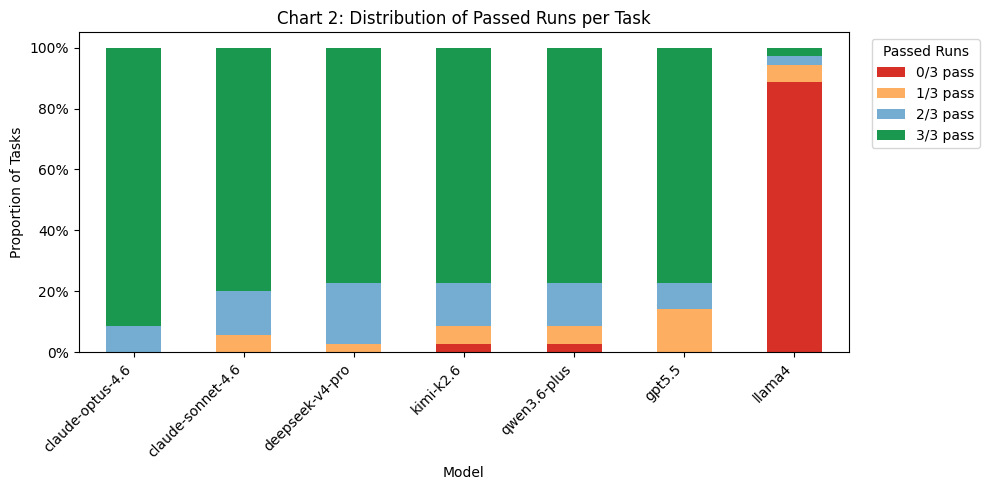

In [32]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

display(passed_runs_distribution_proportion)

ax = passed_runs_distribution_proportion.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5),
    color=["#d73027", "#fdae61", "#74add1", "#1a9850"],
)
ax.set_title("Chart 2: Distribution of Passed Runs per Task")
ax.set_xlabel("Model")
ax.set_ylabel("Proportion of Tasks")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(title="Passed Runs", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Macro-Average PSV and CCR Across Repeated Runs

This table reports the macro-average parameter schema valid rate (PSV) and constraint compliance rate (CCR) over the three runs for each model. For each run, PSV and CCR are first averaged across tasks, and then the model-level mean and standard deviation are computed across the three run-level values.

In [33]:
psv_ccr_by_run = (
    task_runs_with_order[task_runs_with_order["run_order"].isin([1, 2, 3])]
    .groupby(["model_name", "run_order"], as_index=False)
    .agg(
        run_psv=("parameter_schema_valid_rate", "mean"),
        run_ccr=("constraint_compliance_rate", "mean"),
    )
)

psv_ccr_macro_summary = (
    psv_ccr_by_run.groupby("model_name", as_index=False).agg(
        mean_psv=("run_psv", "mean"),
        sd_psv=("run_psv", "std"),
        mean_ccr=("run_ccr", "mean"),
        sd_ccr=("run_ccr", "std"),
    )
)

psv_ccr_macro_summary_display = psv_ccr_macro_summary.assign(
    **{
        "Model": lambda df: df["model_name"],
        "Mean PSV ± SD": lambda df: df.apply(
            lambda row: f"{row['mean_psv']:.4f} +/- {row['sd_psv']:.4f}", axis=1
        ),
        "Mean CCR ± SD": lambda df: df.apply(
            lambda row: f"{row['mean_ccr']:.4f} +/- {row['sd_ccr']:.4f}", axis=1
        ),
    }
)[["Model", "Mean PSV ± SD", "Mean CCR ± SD"]]

display(psv_ccr_macro_summary_display.sort_values("Model"))

,Model,Mean PSV ± SD,Mean CCR ± SD
0,claude-optus-4.6,1.0000 +/- 0.0000,0.9173 +/- 0.0022
1,claude-sonnet-4.6,1.0000 +/- 0.0000,0.9131 +/- 0.0038
2,deepseek-v4-pro,1.0000 +/- 0.0000,0.9007 +/- 0.0110
3,gpt5.5,0.9981 +/- 0.0033,1.0000 +/- 0.0000
4,kimi-k2.6,1.0000 +/- 0.0000,0.9130 +/- 0.0067
5,llama4,0.9861 +/- 0.0241,0.7702 +/- 0.0151
6,qwen3.6-plus,1.0000 +/- 0.0000,0.9192 +/- 0.0078


## Efficiency Metrics Across Repeated Runs

This table reports efficiency-related metrics for each model across the three runs. For each run, each metric is first averaged across tasks, and then the model-level mean and standard deviation are computed across the three run-level values.

In [34]:
efficiency_by_run = (
    task_runs_with_order[task_runs_with_order["run_order"].isin([1, 2, 3])]
    .groupby(["model_name", "run_order"], as_index=False)
    .agg(
        run_total_tokens=("total_tokens", "mean"),
        run_latency=("latency", "mean"),
        run_end_to_end_latency=("end_to_end_latency", "mean"),
        run_total_steps=("total_steps", "mean"),
        run_total_tool_calls=("total_tool_calls", "mean"),
        run_attempt_count=("attempt_count", "mean"),
    )
)

efficiency_metrics_summary = (
    efficiency_by_run.groupby("model_name", as_index=False).agg(
        mean_total_tokens=("run_total_tokens", "mean"),
        sd_total_tokens=("run_total_tokens", "std"),
        mean_latency=("run_latency", "mean"),
        sd_latency=("run_latency", "std"),
        mean_end_to_end_latency=("run_end_to_end_latency", "mean"),
        sd_end_to_end_latency=("run_end_to_end_latency", "std"),
        mean_total_steps=("run_total_steps", "mean"),
        sd_total_steps=("run_total_steps", "std"),
        mean_total_tool_calls=("run_total_tool_calls", "mean"),
        sd_total_tool_calls=("run_total_tool_calls", "std"),
        mean_attempt_count=("run_attempt_count", "mean"),
        sd_attempt_count=("run_attempt_count", "std"),
    )
)

efficiency_metrics_summary_display = efficiency_metrics_summary.assign(
    **{
        "Model": lambda df: df["model_name"],
        "Mean Total Tokens +/- SD": lambda df: df.apply(
            lambda row: f"{row['mean_total_tokens']:,.2f} +/- {row['sd_total_tokens']:,.2f}", axis=1
        ),
        "Mean Latency +/- SD": lambda df: df.apply(
            lambda row: f"{row['mean_latency']:.2f} +/- {row['sd_latency']:.2f}", axis=1
        ),
        "Mean End-to-End Latency +/- SD": lambda df: df.apply(
            lambda row: f"{row['mean_end_to_end_latency']:.2f} +/- {row['sd_end_to_end_latency']:.2f}", axis=1
        ),
        "Mean Steps +/- SD": lambda df: df.apply(
            lambda row: f"{row['mean_total_steps']:.2f} +/- {row['sd_total_steps']:.2f}", axis=1
        ),
        "Mean Tool Calls +/- SD": lambda df: df.apply(
            lambda row: f"{row['mean_total_tool_calls']:.2f} +/- {row['sd_total_tool_calls']:.2f}", axis=1
        ),
        "Mean Attempts +/- SD": lambda df: df.apply(
            lambda row: f"{row['mean_attempt_count']:.2f} +/- {row['sd_attempt_count']:.2f}", axis=1
        ),
    }
)[[
    "Model",
    "Mean Total Tokens +/- SD",
    "Mean Latency +/- SD",
    "Mean End-to-End Latency +/- SD",
    "Mean Steps +/- SD",
    "Mean Tool Calls +/- SD",
    "Mean Attempts +/- SD",
]]

display(efficiency_metrics_summary_display.sort_values("Model"))

,Model,Mean Total Tokens +/- SD,Mean Latency +/- SD,Mean End-to-End Latency +/- SD,Mean Steps +/- SD,Mean Tool Calls +/- SD,Mean Attempts +/- SD
0,claude-optus-4.6,"19,048.64 +/- 309.90",24.54 +/- 0.55,32.03 +/- 0.71,3.10 +/- 0.02,4.78 +/- 0.24,1.00 +/- 0.00
1,claude-sonnet-4.6,"21,043.42 +/- 682.51",23.34 +/- 0.76,30.69 +/- 0.91,3.33 +/- 0.09,5.18 +/- 0.02,1.00 +/- 0.00
2,deepseek-v4-pro,"28,279.14 +/- 2,142.18",52.96 +/- 4.53,60.06 +/- 5.01,4.41 +/- 0.21,6.91 +/- 0.48,1.00 +/- 0.00
3,gpt5.5,"10,323.22 +/- 962.67",22.46 +/- 0.94,29.84 +/- 1.32,2.94 +/- 0.12,4.83 +/- 0.48,1.00 +/- 0.00
4,kimi-k2.6,"22,186.23 +/- 1,303.41",83.54 +/- 10.13,90.92 +/- 10.12,4.13 +/- 0.20,7.13 +/- 0.49,1.00 +/- 0.00
5,llama4,"10,201.04 +/- 1,418.03",20.76 +/- 4.96,26.39 +/- 5.17,2.62 +/- 0.35,1.92 +/- 0.32,1.00 +/- 0.00
6,qwen3.6-plus,"23,452.59 +/- 1,267.42",53.42 +/- 3.91,60.46 +/- 3.77,4.13 +/- 0.12,6.04 +/- 0.41,1.00 +/- 0.00


## Optional Export

Set `EXPORT_CSV = True` in the configuration cell if you want these tables written to `analysis/outputs/`.

In [35]:
if EXPORT_CSV:
    OUTPUT_DIR.mkdir(exist_ok=True)
    reports_df.to_csv(OUTPUT_DIR / "all_reports_summary.csv", index=False)
    task_runs_df.to_csv(OUTPUT_DIR / "all_task_runs.csv", index=False)
    tool_scores_df.to_csv(OUTPUT_DIR / "all_tool_scores.csv", index=False)
    model_summary.to_csv(OUTPUT_DIR / "all_model_summary.csv", index=False)
    tcr_by_task_category_at_1_table.to_csv(OUTPUT_DIR / "tcr_by_task_category_at_1.csv", index=False)
    overall_task_completion_performance_at_3_table.to_csv(OUTPUT_DIR / "overall_task_completion_performance_at_3.csv", index=True)
    task_completion_performance_hat_1_table.to_csv(OUTPUT_DIR / "task_completion_performance_hat_1.csv", index=True)
    task_completion_performance_hat_1_by_demand_profile_table.to_csv(OUTPUT_DIR / "task_completion_performance_hat_1_by_demand_profile.csv", index=True)
    reliability_repeated_runs.to_csv(OUTPUT_DIR / "reliability_repeated_runs.csv", index=False)
    passed_runs_distribution_counts.reset_index().to_csv(OUTPUT_DIR / "passed_runs_distribution_counts.csv", index=False)
    passed_runs_distribution_proportion.reset_index().to_csv(OUTPUT_DIR / "passed_runs_distribution_proportion.csv", index=False)
    psv_ccr_macro_summary.to_csv(OUTPUT_DIR / "psv_ccr_macro_summary.csv", index=False)
    efficiency_metrics_summary.to_csv(OUTPUT_DIR / "efficiency_metrics_summary.csv", index=False)
    tool_use_by_category.to_csv(OUTPUT_DIR / "tool_use_by_category.csv", index=False)
    print(f"Exported CSVs to {OUTPUT_DIR}")
else:
    print("CSV export skipped. Set EXPORT_CSV = True to write output files.")

CSV export skipped. Set EXPORT_CSV = True to write output files.
